In [3]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])

In [4]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [5]:
# Medidas de posición
import numpy as np
import matplotlib.pyplot as plt

Q1 = np.percentile(X, 25)
Q3 = np.percentile(X, 75)
RIC = Q3 - Q1
lim_inf = Q1 - 1.5*RIC
lim_sup = Q3 + 1.5*RIC

print('RIC :', RIC)
print('limite inferior :', lim_inf)
print('limite superior :', lim_sup)

RIC : 20.25
limite inferior : -40.625
limite superior : 40.375


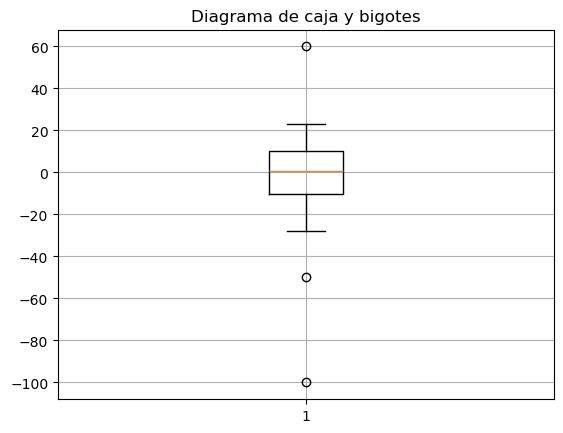

In [6]:
# Dibuja el diagrama de box and whiskers y determina visualmente el número de outliers
plt.boxplot(X)
plt.grid()
plt.title("Diagrama de caja y bigotes")
plt.show()

In [7]:
# Medidas de dispersión
desvest = np.std(X)
print('Desviación típica: ', desvest)
print('Varianza: ', desvest**2)

Desviación típica:  33.521242681880096
Varianza:  1123.6737109375


In [8]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [10]:
# Cargar el set de datos de Iris
from sklearn import datasets
from pprint import pprint
iris = datasets.load_iris()
#pprint(iris)
X = iris.data
y = iris.target

# ¿Qué tipo de asimetría se observa en la variable "longitud del pétalo"?
longitud_petalo = X[:, 2]
asimetria = stats.skew(longitud_petalo)
print(f"Asimetría de la longitud del pétalo: {np.round(asimetria, 4)}")

if asimetria > 0:
    print("Tiene asimetria positiva.")
elif asimetria < 0:
    print(" Tiene asimetria negativa.")
else:
    print(" Es simétrica.")

print("-" * 40)

# ¿A qué tipo de distribución se ajusta la variable "ancho del sépalo", según su curtosis?
ancho_sepalo = X[:, 1]
# CONSULTA(use fisher=true para que la distribucion normal sea 0)
curtosis = stats.kurtosis(ancho_sepalo, fisher=True) 
print(f"Curtosis del ancho del sépalo: {np.round(curtosis, 4)}")

if curtosis > 0:
    print('Distribución Leptocurtica (muy apuntada).')
elif curtosis < 0:
    print('Distribución Platicurtica (muy achatada).')
else:
    print('Distribución Mesocurtica (similar a la normal).')

Asimetría de la longitud del pétalo: -0.2721
 Tiene asimetria negativa.
----------------------------------------
Curtosis del ancho del sépalo: 0.181
Distribución Leptocurtica (muy apuntada).


In [14]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
import matplotlib.pyplot as plt

In [12]:
nombres_variables = iris.feature_names
nombres_clases = iris.target_names
clases = np.unique(y)
plt.figure(figsize=(10, 6))
colores = ['red', 'green', 'blue']
posiciones_x = np.arange(len(nombres_variables))

In [ ]:
#Aqui itero cada tipo de flor
for i, clase in enumerate(clases):
    # Filtra solo los datos de la flor actual
    datos_flor = X[y == clase]
    
    # Calculo la media y desviación estándar de sus 4 características
    medias = np.mean(datos_flor, axis=0)
    desviaciones = np.std(datos_flor, axis=0)
    
    # Dibujo las barras de error. 
    # Le sumo (i*0.1) a X para que los puntos no se pongan encima de otros
    plt.errorbar(posiciones_x + (i * 0.1), medias, yerr=desviaciones, 
                 fmt='o', color=colores[i], label=nombres_clases[clase],
                 capsize=5, elinewidth=2, markersize=7)

In [13]:
#Aqui hago el etiquetado y el dise;o
plt.xticks(posiciones_x + 0.1, nombres_variables)
plt.title('Media y Desviación Típica por Clase y Variable (Iris Dataset)')
plt.ylabel('Centímetros (cm)')
plt.legend(title="Tipos de Flor")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

<class 'NameError'>: name 'posiciones_x' is not defined

El resultado debería ser algo como esto:
<img src="images/errorbar.png">